In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression

In [2]:
import pandas as pd
df = pd.read_csv("loan_data.csv")

In [3]:
df.head()

df.tail()

df.info()

df.describe()

df.shape

df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  45000 non-null  int64  
 1   Gender               45000 non-null  object 
 2   Education            45000 non-null  object 
 3   Person Income        45000 non-null  int64  
 4   Employee Experience  45000 non-null  int64  
 5   Home Onwership       45000 non-null  object 
 6   Loan Amount          45000 non-null  int64  
 7   Loan Intent          45000 non-null  object 
 8   Loan interest Rate   45000 non-null  float64
 9   Loan percentage      45000 non-null  float64
 10  Credit History       45000 non-null  int64  
 11  Credit Score         45000 non-null  int64  
 12  Previous Loan        45000 non-null  object 
 13  Loan Status          45000 non-null  int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 4.8+ MB


Index(['Age', 'Gender', 'Education', 'Person Income', 'Employee Experience',
       'Home Onwership', 'Loan Amount', 'Loan Intent', 'Loan interest Rate',
       'Loan percentage', 'Credit History', 'Credit Score', 'Previous Loan',
       'Loan Status'],
      dtype='object')

In [4]:
df.isnull().sum()


,0
Age,0
Gender,0
Education,0
Person Income,0
Employee Experience,0
Home Onwership,0
Loan Amount,0
Loan Intent,0
Loan interest Rate,0
Loan percentage,0


In [5]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)


/tmp/ipykernel_1228/700870124.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)


In [6]:
df['Loan Amount'].fillna(df['Loan Amount'].median(), inplace=True)

/tmp/ipykernel_1228/2133991300.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Loan Amount'].fillna(df['Loan Amount'].median(), inplace=True)


In [7]:
from sklearn.preprocessing import LabelEncoder


In [8]:
encoder = LabelEncoder()

In [9]:
df.dtypes

,0
Age,int64
Gender,object
Education,object
Person Income,int64
Employee Experience,int64
Home Onwership,object
Loan Amount,int64
Loan Intent,object
Loan interest Rate,float64
Loan percentage,float64


In [10]:
df["Gender"] = encoder.fit_transform(df["Gender"])

In [11]:
df["Gender"].head()

,Gender
0,0
1,0
2,0
3,0
4,1


In [12]:
df["Education"] = encoder.fit_transform(df["Education"])

In [13]:
df["Education"].head()

,Education
0,4
1,3
2,3
3,1
4,4


In [14]:
df["Home Onwership"] = encoder.fit_transform(df["Home Onwership"])

In [15]:
df["Home Onwership"].head()

,Home Onwership
0,3
1,2
2,0
3,3
4,3


In [16]:
df["Loan Intent"] = encoder.fit_transform(df["Loan Intent"])

In [17]:
df["Loan Intent"].head()

,Loan Intent
0,4
1,1
2,3
3,3
4,3


In [18]:
df["Previous Loan"] = encoder.fit_transform(df["Previous Loan"])

In [19]:
df["Previous Loan"].head()

,Previous Loan
0,0
1,1
2,0
3,0
4,0


In [20]:
df.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,0,4,71948,0,3,35000,4,16.02,0.49,3,561,0,1
1,21,0,3,12282,0,2,1000,1,11.14,0.08,2,504,1,0
2,25,0,3,12438,3,0,5500,3,12.87,0.44,3,635,0,1
3,23,0,1,79753,0,3,35000,3,15.23,0.44,2,675,0,1
4,24,1,4,66135,1,3,35000,3,14.27,0.53,4,586,0,1


In [21]:
df.isnull().sum()

,0
Age,0
Gender,0
Education,0
Person Income,0
Employee Experience,0
Home Onwership,0
Loan Amount,0
Loan Intent,0
Loan interest Rate,0
Loan percentage,0


In [22]:
X = df.drop("Loan Status", axis=1)
y = df["Loan Status"]

In [23]:
X.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan
0,22,0,4,71948,0,3,35000,4,16.02,0.49,3,561,0
1,21,0,3,12282,0,2,1000,1,11.14,0.08,2,504,1
2,25,0,3,12438,3,0,5500,3,12.87,0.44,3,635,0
3,23,0,1,79753,0,3,35000,3,15.23,0.44,2,675,0
4,24,1,4,66135,1,3,35000,3,14.27,0.53,4,586,0


In [24]:
y.head()

,Loan Status
0,1
1,0
2,1
3,1
4,1


In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(36000, 13)
(9000, 13)
(36000,)
(9000,)


In [28]:
from sklearn.linear_model import LogisticRegression

In [29]:
model = LogisticRegression()

In [30]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [31]:
y_pred = model.predict(X_test)

In [32]:
from sklearn.metrics import accuracy_score

In [33]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8273333333333334


In [34]:
from sklearn.tree import DecisionTreeClassifier

In [35]:
dt_model = DecisionTreeClassifier(random_state=42)

In [36]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [37]:
dt_pred = dt_model.predict(X_test)

In [38]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.8981111111111111


In [39]:
from sklearn.ensemble import RandomForestClassifier

In [40]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [41]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [42]:
rf_pred = rf_model.predict(X_test)

In [43]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9286666666666666


In [44]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.827333
1,Decision Tree,0.898111
2,Random Forest,0.928667


In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

print(cm)

[[6797  193]
 [ 449 1561]]


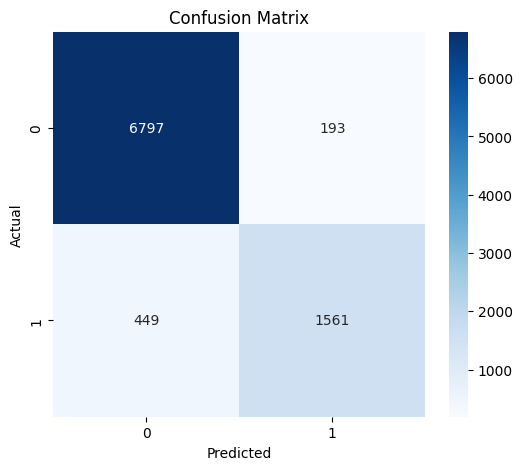

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [47]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95      6990
           1       0.89      0.78      0.83      2010

    accuracy                           0.93      9000
   macro avg       0.91      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000



In [48]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
12,Previous Loan,0.220710
9,Loan percentage,0.170466
8,Loan interest Rate,0.159659
3,Person Income,0.128532
5,Home Onwership,0.063213
6,Loan Amount,0.059705
11,Credit Score,0.056180
7,Loan Intent,0.035479
0,Age,0.029439
4,Employee Experience,0.027306


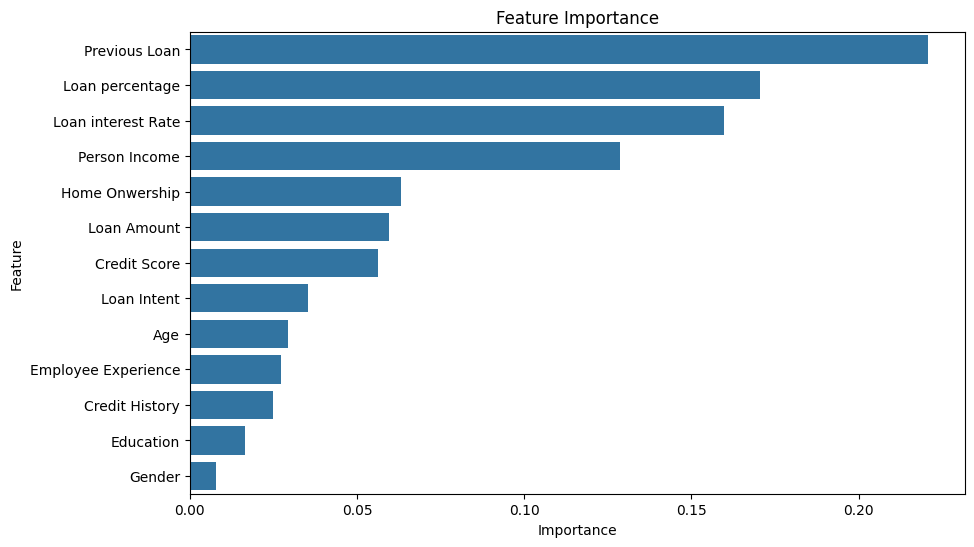

In [49]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

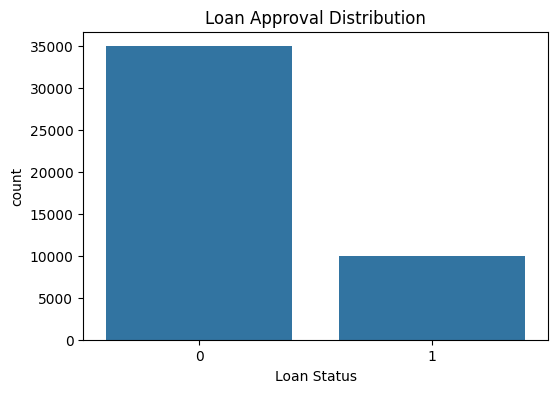

In [50]:
plt.figure(figsize=(6,4))
sns.countplot(x="Loan Status", data=df)
plt.title("Loan Approval Distribution")
plt.show()

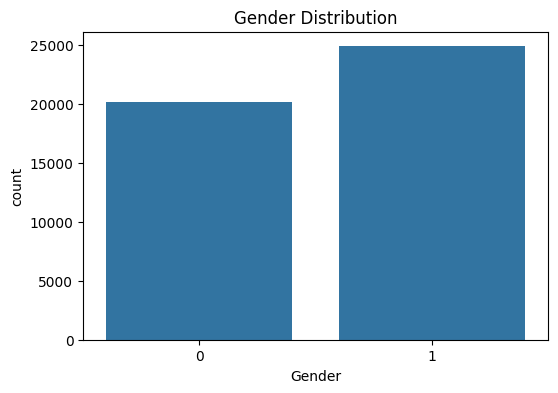

In [51]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

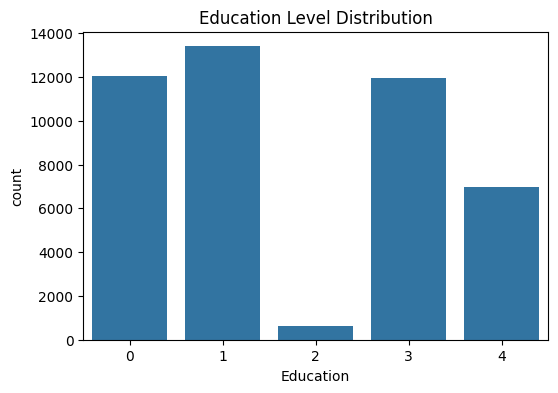

In [52]:
plt.figure(figsize=(6,4))
sns.countplot(x="Education", data=df)
plt.title("Education Level Distribution")
plt.show()

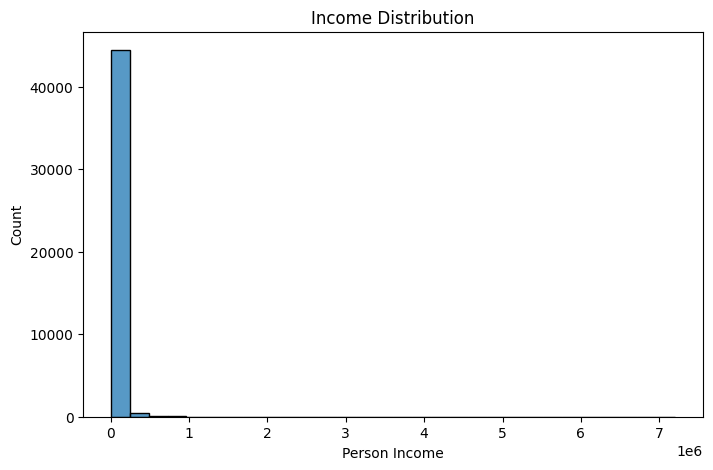

In [53]:
plt.figure(figsize=(8,5))
sns.histplot(df["Person Income"], bins=30)
plt.title("Income Distribution")
plt.show()

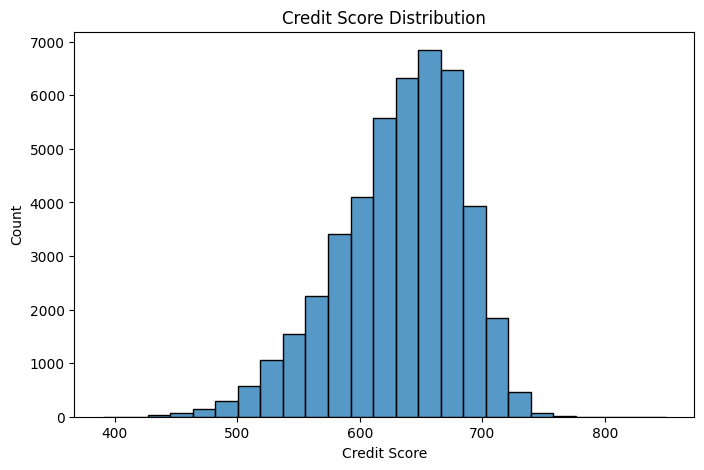

In [54]:
plt.figure(figsize=(8,5))
sns.histplot(df["Credit Score"], bins=25)
plt.title("Credit Score Distribution")
plt.show()

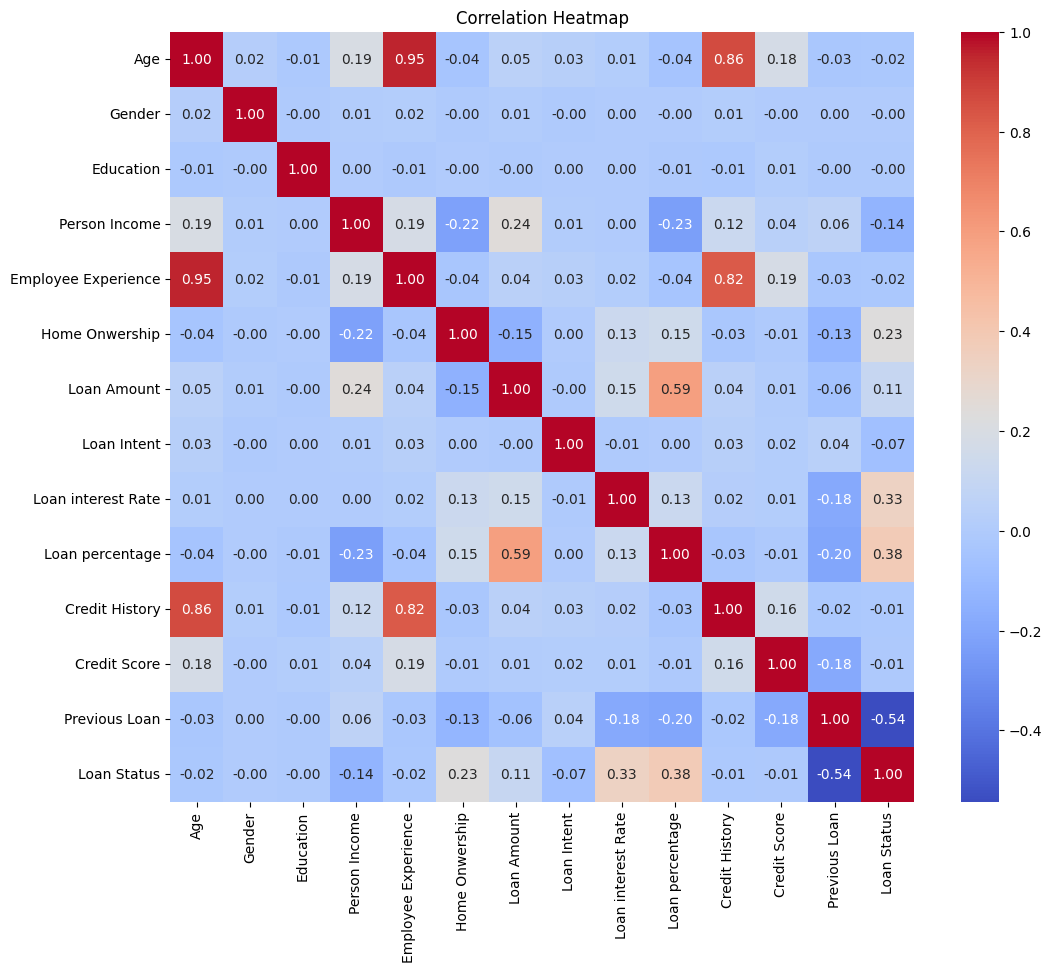

In [55]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [56]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.827333
1,Decision Tree,0.898111
2,Random Forest,0.928667


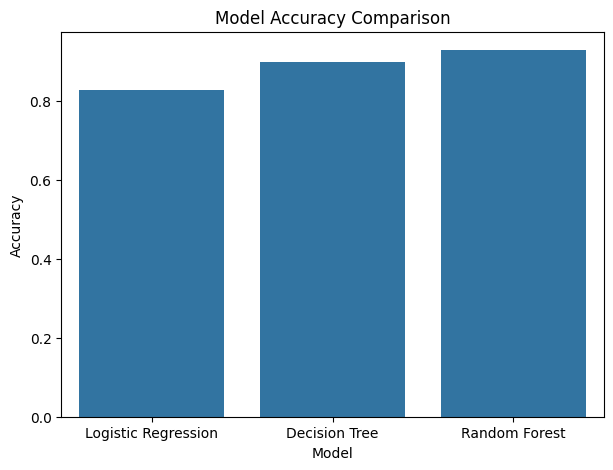

In [57]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")

plt.show()

In [58]:
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [59]:
sample = pd.DataFrame({
    "Age":[25],
    "Gender":[1],
    "Education":[4],
    "Person Income":[65000],
    "Employee Experience":[3],
    "Home Onwership":[2],
    "Loan Amount":[20000],
    "Loan Intent":[2],
    "Loan interest Rate":[10.5],
    "Loan percentage":[0.25],
    "Credit History":[4],
    "Credit Score":[720],
    "Previous Loan":[1]
})

prediction = rf_model.predict(sample)

print(prediction)

[0]


In [60]:
if prediction[0]==1:
    print("Loan Approved")
else:
    print("Loan Rejected")

Loan Rejected


In [61]:
import joblib

joblib.dump(rf_model, "loan_approval_model.pkl")

['loan_approval_model.pkl']

In [62]:
import os
print(os.listdir())

['.config', 'loan_approval_model.pkl', 'feature_importance.png', 'loan_data.csv', 'sample_data']
